## Código encargado de generar el dataframe principal: elecciones + Market Access.

In [ ]:

### Librerias y funciones 
import pandas as pd
import numpy as np
import os
import unicodedata
import re
import warnings

warnings.filterwarnings('ignore')

# Función de normalización (misma que en reconstruir_comunas_1970.py)
SPELLING_ALIASES = {
    'AYSEN': 'AISEN', 'COYHAIQUE': 'COIHAIQUE',
    'PAIHUANO': 'PAIGUANO', 'TREHUACO': 'TREGUACO',
    'MARCHIGUE': 'MARCHIHUE',
    'CHIGUAYANTE': 'CONCEPCION', 'SAN PEDRO DE LA PAZ': 'CONCEPCION',
    'HUALPEN': 'TALCAHUANO', 'PADRE LAS CASAS': 'TEMUCO',
    'ALTO HOSPICIO': 'IQUIQUE'
}


def normalizar(txt):
    if pd.isna(txt): return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt)
    return SPELLING_ALIASES.get(txt, txt)

# Rutas
PATH_MA        = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad.csv'
PATH_MAPPING   = '/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/mapping_1970_2024.csv'
PATH_POBLACION = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/población/Consolidado informacion censos historicos .xlsx'
PATH_ELEC_88   = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/Resultados_plebiscito_88.dta'
PATH_PLEB_22   = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/Resultados_plebiscito_2022.dta'
PATH_PLEB_20   = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/plebiscito 2020/Resultados-Plebiscito-Constitucion-Politica-2020.xlsx'
PATH_OUT       = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/'



In [ ]:

###  CONSTRUIR MAPPING HIJA→MADRE ###

# Cargar mapping 1970-2024
df_mapping = pd.read_csv(PATH_MAPPING)
df_mapping['hija_norm']  = df_mapping['daughter_2024'].apply(normalizar)
df_mapping['madre_norm'] = df_mapping['mother_1970'].apply(normalizar)

hija_a_madre = pd.Series(
    df_mapping.madre_norm.values,
    index=df_mapping.hija_norm.values
).to_dict()

# Función auxiliar: dado un nombre de comuna 2024, devuelve su madre 1970
def obtener_madre(nombre_2024):
    n = normalizar(nombre_2024)
    return hija_a_madre.get(n, n)

madres_unicas = sorted(set(hija_a_madre.values()))
print(f" Mapping cargado: {len(hija_a_madre)} hijas → {len(madres_unicas)} madres únicas")

# Diccionario de nombres históricos para referencia
RENOMBRAR_MADRES = {
    'AGUAS BLANCAS': 'ANTOFAGASTA', 'BAHIA INUTIL': 'PORVENIR',
    'BAKER': 'TORTEL', 'BARRANCAS': 'LO PRADO', 'BELEN': 'PUTRE',
    'CATALINA': 'TALTAL', 'CERRO CASTILLO': 'TORRES DEL PAINE',
    'CODPA': 'CAMARONES', 'GENERAL CARRERA': 'CHILE CHICO',
    'LA CALERA': 'HIJUELAS', 'LAGO RANGO': 'FUTRONO',
    'LAGUNAS': 'POZO ALMONTE', 'LLAYLLAY': 'LLAILLAY',
    'MAGALLANES': 'PUNTA ARENAS', 'MINCHA': 'CANELA',
    'MORRO CHICO': 'LAGUNA BLANCA', 'NAVARINO': 'CABO DE HORNOS',
    'NEGREIROS': 'COLCHANE', 'PISAGUA': 'HUARA',
    'QUILECO': 'QUILLECO', 'ROSARIO': 'LITUECHE',
    'SAMO ALTO': 'RIO HURTADO', 'TOCO': 'MARIA ELENA',
}
print(f" Diccionario RENOMBRAR_MADRES con {len(RENOMBRAR_MADRES)} comunas disponible.")

## Elecciones Plebiscito 1988 - 2020 - 2022 

Nota: se debe actualizar para que las variables generadas en esta sección se unan al dataframe final para poder generar la data desde 0 como en versiones anteriores.

In [ ]:

### PLEBISCITO 1988 — AGREGACIÓN A COMUNAS 1970 ###

print("─── PLEBISCITO 1988 ───")

# 1. Cargar datos electorales (LPA 2024)
df_88 = pd.read_stata(PATH_ELEC_88)
df_88['norm_hija'] = df_88['comuna'].apply(normalizar)

# 2. Asignar madre 1970 a cada comuna
df_88['madre_1970'] = df_88['norm_hija'].apply(obtener_madre)

# 3. Columnas numéricas a sumar
cols_votos_88 = ['vsi_pleb88', 'vno_pleb88', 'total_inscritos_88',
                 'vtotal_pleb88', 'nulos_pleb88', 'blancos_pleb88']

# 4. Agregar votos por comuna madre
df_88_madre = df_88.groupby('madre_1970')[cols_votos_88].sum().reset_index()
df_88_madre.columns = ['comuna'] + cols_votos_88

# 5. Recalcular shares a nivel de madre
df_88_madre['share_si_88'] = df_88_madre['vsi_pleb88'] / df_88_madre['vtotal_pleb88']
df_88_madre['share_no_88'] = df_88_madre['vno_pleb88'] / df_88_madre['vtotal_pleb88']

print(f".  Plebiscito 88 agregado: {len(df_88_madre)} comunas madre")
print(f"   Votos Sí total: {df_88_madre['vsi_pleb88'].sum():,.0f}")
print(f"   Votos No total: {df_88_madre['vno_pleb88'].sum():,.0f}")

# Verificación: comunas hijas que se fusionaron
fusionadas = df_88.groupby('madre_1970')['norm_hija'].apply(list).reset_index()
fusionadas_multi = fusionadas[fusionadas['norm_hija'].apply(len) > 1]
print(f"\n   Comunas madre con múltiples hijas fusionadas: {len(fusionadas_multi)}")
if len(fusionadas_multi) > 0:
    for _, row in fusionadas_multi.head(10).iterrows():
        print(f"     {row['madre_1970']}: {row['norm_hija']}")

display(df_88_madre.head())

In [ ]:

###  PLEBISCITO 2022 — AGREGACIÓN A COMUNAS 1970 ###

print("─── PLEBISCITO 2022 ───")

# 1. Cargar
df_22 = pd.read_stata(PATH_PLEB_22)
df_22 = df_22[df_22['Comuna'].str.strip() != ''].copy()
df_22 = df_22[df_22['Opción'] != 'Total'].copy()

# 2. Normalizar y asignar madre
df_22['norm_hija'] = df_22['Comuna'].apply(normalizar)
df_22['madre_1970'] = df_22['norm_hija'].apply(obtener_madre)

# 3. Agregar votos brutos por madre y opción
df_22_agg = df_22.groupby(['madre_1970', 'Opción'])['VotosTRICEL'].sum().reset_index()

# 4. Pivotear a formato ancho
df_22_pivot = df_22_agg.pivot_table(
    index='madre_1970', columns='Opción', values='VotosTRICEL', aggfunc='sum'
).reset_index()

# 5. Calcular totales y shares
opciones_22 = [c for c in df_22_pivot.columns if c != 'madre_1970']
df_22_pivot['total_votos_22'] = df_22_pivot[opciones_22].sum(axis=1)

# Renombrar columnas limpiamente
col_map_22 = {}
for c in opciones_22:
    c_clean = normalizar(c).lower().replace(' ', '_')
    col_map_22[c] = f'v_{c_clean}_22'
df_22_pivot = df_22_pivot.rename(columns=col_map_22)

# Calcular shares
for old_name, new_name in col_map_22.items():
    share_name = new_name.replace('v_', 'share_')
    df_22_pivot[share_name] = df_22_pivot[new_name] / df_22_pivot['total_votos_22']

df_22_pivot = df_22_pivot.rename(columns={'madre_1970': 'comuna'})

print(f" Plebiscito 2022 agregado: {len(df_22_pivot)} comunas madre")
display(df_22_pivot.head())


In [ ]:
from networkx import display

### PLEBISCITO 2020 — AGREGACIÓN A COMUNAS 1970 ###

print("─── PLEBISCITO 2020 ───")

# 1. Cargar (solo hoja Chile)
df_20 = pd.read_excel(PATH_PLEB_20, sheet_name='Chile')

# 2. Normalizar y asignar madre
df_20['norm_hija'] = df_20['Comuna'].apply(normalizar)
df_20['madre_1970'] = df_20['norm_hija'].apply(obtener_madre)

# 3. Agregar votos por comuna madre y opción
df_20_agg = df_20.groupby(['madre_1970', 'Opción Constitución Política'])['Votos TRICEL'].sum().reset_index()

# 4. Pivotear
df_20_pivot = df_20_agg.pivot_table(
    index='madre_1970',
    columns='Opción Constitución Política',
    values='Votos TRICEL',
    aggfunc='sum'
).reset_index()

# 5. Calcular totales y shares
opciones_20 = [c for c in df_20_pivot.columns if c != 'madre_1970']
df_20_pivot['total_votos_20'] = df_20_pivot[opciones_20].sum(axis=1)

for c in opciones_20:
    c_clean = normalizar(c).lower().replace(' ', '_')
    df_20_pivot[f'share_{c_clean}_20'] = df_20_pivot[c] / df_20_pivot['total_votos_20']
    df_20_pivot = df_20_pivot.rename(columns={c: f'v_{c_clean}_20'})

df_20_pivot = df_20_pivot.rename(columns={'madre_1970': 'comuna'})

print(f" Plebiscito 2020 agregado: {len(df_20_pivot)} comunas madre")
display(df_20_pivot.head())



## Actualización valores dataframe final: Elecciones 1988-2020-2022 y presidenciales + diputado

In [ ]:
## NOTA: Correr desde acá para actualizar valores de la data market_access_comunas1970_sensibilidad.csv

#import pandas as pd

# 1. Asegurarse de cargar la base (Ajusta la ruta si es diferente)
#PATH_FINAL_DF = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad.csv'
#df_ma = pd.read_csv(PATH_FINAL_DF)

# Base: Market Access (ya a nivel de comunas 1970)
#final_df = df_ma.copy()
#print(f"Base MA: {len(final_df)} comunas")

Base MA: 279 comunas


In [ ]:
###  MERGE FINAL — MA + ELECCIONES ###
import geopandas as gpd

print("─── MERGE FINAL ───")

# Base: Market Access (ya a nivel de comunas 1970)
final_df = df_ma.copy()

#  FIX DEFINITIVO: Eliminar cualquier columna que vayamos a mergear
# Esto evita que se creen columnas _x y _y si el archivo CSV ya las traía de antes.
for col in final_df.columns:
    if any(k in col for k in ['pleb88', '_22', '_20', 'urbano_', 'rural_', 'pct_', 'share_', 'region', 'provincia', 'departamento', 'delta_right']):
        final_df.drop(columns=[col], inplace=True)

print(f"Base MA limpia: {len(final_df)} comunas")

# Merge Plebiscito 1988
final_df = final_df.merge(df_88_madre, on='comuna', how='left')
n_88 = final_df['vtotal_pleb88'].notna().sum()
print(f"+ Pleb 1988: {n_88} comunas con datos")

# Merge Plebiscito 2022
final_df = final_df.merge(df_22_pivot, on='comuna', how='left')
n_22 = final_df['total_votos_22'].notna().sum()
print(f"+ Pleb 2022: {n_22} comunas con datos")

# Merge Plebiscito 2020
final_df = final_df.merge(df_20_pivot, on='comuna', how='left')
n_20 = final_df['total_votos_20'].notna().sum()
print(f"+ Pleb 2020: {n_20} comunas con datos")

# Añadir ruralidad (censo 1992) y Población
path_censo = PATH_POBLACION
df_censo = pd.read_excel(path_censo)
df_censo['norm_censo'] = df_censo['Nombre Comuna'].apply(normalizar)
df_censo['madre_1970'] = df_censo['norm_censo'].apply(obtener_madre)

df_rural = df_censo.groupby('madre_1970').agg(
    urbano_1992=('Urbano 1992', 'sum'),
    rural_1992=('Rural 1992', 'sum')
).reset_index()
df_rural.columns = ['comuna', 'urbano_1992', 'rural_1992']
df_rural['urbano_1992'] = pd.to_numeric(df_rural['urbano_1992'], errors='coerce').fillna(0)
df_rural['rural_1992'] = pd.to_numeric(df_rural['rural_1992'], errors='coerce').fillna(0)
df_rural['pob_total_1992'] = df_rural['urbano_1992'] + df_rural['rural_1992']
df_rural['share_rural_1992'] = df_rural['rural_1992'] / df_rural['pob_total_1992']

final_df = final_df.merge(df_rural, on='comuna', how='left')


# Añadir Región (Actual) y Provincia Histórica (1970)


# 1. Extraer la Región moderna del Censo 1992 (ya que en 1970 no existían las regiones)
df_geo = pd.read_excel(PATH_POBLACION)
df_geo['norm_censo'] = df_geo['Nombre Comuna'].apply(normalizar)
df_geo['madre_1970'] = df_geo['norm_censo'].apply(obtener_madre)

df_reg = df_geo.groupby('madre_1970').agg(
    region_actual=('Region', 'first')
).reset_index()
df_reg.columns = ['comuna', 'region_actual']

# 2. Extraer la Provincia Histórica desde el Shapefile 1970
path_shp_1970 = '/Users/Angelo/Dropbox/DPA Historica/Comunas_1970.shp'

# EL FIX MAGICO: Agregar encoding='utf-8' para que lea bien la Ñ y los acentos
gdf_1970 = gpd.read_file(path_shp_1970, encoding='utf-8')

# Normalizamos el nombre de la comuna
gdf_1970['comuna'] = gdf_1970['COMUNA'].apply(normalizar)

# Arreglo: El shapefile histórico le llama "AYSEN" pero la base "AISEN"
gdf_1970['comuna'] = gdf_1970['comuna'].replace({'AYSEN': 'AISEN'})

# Normalizamos el nombre de la provincia
gdf_1970['provincia_1970'] = gdf_1970['PROVINCIA'].apply(normalizar)

# Extraemos Provincia (y Departamento si existe)
if 'DEPARTAMEN' in gdf_1970.columns:
    gdf_1970['departamento_1970'] = gdf_1970['DEPARTAMEN'].apply(normalizar)
    df_prov_1970 = gdf_1970[['comuna', 'provincia_1970', 'departamento_1970']].drop_duplicates()
else:
    df_prov_1970 = gdf_1970[['comuna', 'provincia_1970']].drop_duplicates()

# 3. Mergear a la base final
final_df = final_df.merge(df_reg, on='comuna', how='left')
final_df = final_df.merge(df_prov_1970, on='comuna', how='left')

# Verificaciones
n_con_prov = final_df['provincia_1970'].notna().sum()
print(f" Región (Actual) y Provincia (1970) añadidas: {n_con_prov} de {len(final_df)} comunas")

sin_prov = final_df[final_df['provincia_1970'].isna()]['comuna'].tolist()
if sin_prov:
    print(f"    Sin provincia (revisar nombres): {sin_prov}")

print(f"\n Base final: {len(final_df)} comunas, {len(final_df.columns)} columnas")
print(f"   Columnas: {final_df.columns.tolist()}")


## Merge estimación Market Access IV.

In [ ]:
#  MERGE IV LOCAL: Deltas de sensibilidad con mejoras locales apagadas ───

PATH_IV_LOCAL = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad_LOCAL.csv'
df_iv = pd.read_csv(PATH_IV_LOCAL)

# Seleccionar solo columnas de delta + comuna
cols_delta_iv = [c for c in df_iv.columns if c.startswith('delta_')]
df_iv_merge = df_iv[['comuna'] + cols_delta_iv].copy()

# Renombrar con sufijo _local
rename_iv = {c: c + '_local' for c in cols_delta_iv}
df_iv_merge = df_iv_merge.rename(columns=rename_iv)

# Merge con la base final
final_df = final_df.merge(df_iv_merge, on='comuna', how='left')

n_iv = final_df[rename_iv[cols_delta_iv[0]]].notna().sum()
print(f" IV LOCAL mergeado: {n_iv} comunas con datos")
print(f"   Columnas añadidas: {list(rename_iv.values())}")


In [ ]:
# ─── MERGE IV PROVINCIAL: Deltas de sensibilidad con mejoras provinciales apagadas ───

PATH_IV_PROV = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/market_access_comunas1970_sensibilidad_PROV.csv'
df_iv_prov = pd.read_csv(PATH_IV_PROV)

# Seleccionar solo columnas de delta + comuna
cols_delta_iv_prov = [c for c in df_iv_prov.columns if c.startswith('delta_')]
df_iv_prov_merge = df_iv_prov[['comuna'] + cols_delta_iv_prov].copy()

# Renombrar con sufijo _prov
rename_iv_prov = {c: c + '_prov' for c in cols_delta_iv_prov}
df_iv_prov_merge = df_iv_prov_merge.rename(columns=rename_iv_prov)

# Merge con la base final (final_df)
final_df = final_df.merge(df_iv_prov_merge, on='comuna', how='left')

# Verificación
col_check = list(rename_iv_prov.values())[0]
n_iv_prov = final_df[col_check].notna().sum()
print(f" IV PROVINCIAL mergeado: {n_iv_prov} comunas con datos")
print(f"   Columnas añadidas: {list(rename_iv_prov.values())}")


In [ ]:
###  VERIFICACIÓN DE COBERTURA ###

print("─── VERIFICACIÓN ───")

# Comunas del panel MA sin datos electorales
sin_88 = final_df[final_df['vtotal_pleb88'].isna()]['comuna'].tolist()
sin_22 = final_df[final_df['total_votos_22'].isna()]['comuna'].tolist()
sin_20 = final_df[final_df['total_votos_20'].isna()]['comuna'].tolist()

print(f"Comunas MA sin Pleb 1988: {len(sin_88)}")
if sin_88: print(f"  {sin_88[:15]}...")

print(f"Comunas MA sin Pleb 2022: {len(sin_22)}")
if sin_22: print(f"  {sin_22[:15]}...")

print(f"Comunas MA sin Pleb 2020: {len(sin_20)}")
if sin_20: print(f"  {sin_20[:15]}...")

# Estadísticas rápidas del plebiscito 88
if 'share_si_88' in final_df.columns:
    print(f"\n--- Plebiscito 1988 (comunas 1970) ---")
    print(f"  Share Sí promedio: {final_df['share_si_88'].mean():.4f}")
    print(f"  Share No promedio: {final_df['share_no_88'].mean():.4f}")


### CELDA 9: EXPORTAR A STATA ###

# Limpiar nombres de columnas para Stata
def clean_col(c):
    c = str(c).replace('.', '_').replace(' ', '_').replace('-', '_').lower()
    c = re.sub(r'[^a-z0-9_]', '', c)
    return c[:31]

final_df.columns = [clean_col(c) for c in final_df.columns]

# Exportar
out_dta = PATH_OUT + 'base_unificada_ma_elecciones_comunas1970.dta'
out_csv = PATH_OUT + 'base_unificada_ma_elecciones_comunas1970.csv'

try:
    final_df.to_stata(out_dta, write_index=False, version=118)
    print(f"✅ Exportado a Stata: {out_dta}")
except Exception as e:
    print(f" Error DTA: {e}")

final_df.to_csv(out_csv, index=False)
print(f" Exportado a CSV: {out_csv}")
print(f"   Total filas: {len(final_df)}, columnas: {len(final_df.columns)}")


─── VERIFICACIÓN ───
Comunas MA sin Pleb 1988: 0
Comunas MA sin Pleb 2022: 1
  ['NAVARINO']...
Comunas MA sin Pleb 2020: 1
  ['NAVARINO']...

--- Plebiscito 1988 (comunas 1970) ---
  Share Sí promedio: 0.5072
  Share No promedio: 0.4673
✅ Exportado a Stata: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/base_unificada_ma_elecciones_comunas1970.dta
✅ Exportado a CSV: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/base_unificada_ma_elecciones_comunas1970.csv
   Total filas: 279, columnas: 67


In [ ]:
### CELDA: CARGAR ELECCIONES ORIGINALES (POR COMUNA HIJA).

import pandas as pd
import unicodedata, re

PATH_ELEC_ORIG = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/elecciones_agregado.dta'

df_elec_raw = pd.read_stata(PATH_ELEC_ORIG)
df_elec_raw['norm'] = df_elec_raw['comuna'].apply(normalizar)
df_elec_raw['madre'] = df_elec_raw['norm'].apply(lambda x: hija_a_madre.get(x, x))

print(f"✅ Datos electorales cargados: {df_elec_raw.shape[0]} filas, {df_elec_raw['madre'].nunique()} comunas madre")
print(f"   Sexo: {df_elec_raw['sexo'].value_counts().to_dict()}")


✅ Datos electorales cargados: 692 filas, 286 comunas madre
   Sexo: {0.0: 346, 1.0: 346}


In [ ]:
### CELDA: CONSTRUIR SHARE DERECHA PARA TODAS LAS ELECCIONES Y MERGEAR ###

# ── Definición de elecciones: qué partidos/candidatos son "derecha" ──
elections_config = {
    # Plebiscito 1988
    'share_si_88':          {'der': ['vsi_pleb88'],                   'tot': 'vtotal_pleb88'},
    # Presidenciales
    'share_der_pres89':     {'der': ['vbuchi_89'],                    'tot': 'votos_pres89'},
    'share_der_pres93':     {'der': ['valessandri_93', 'vjpinera_93'],'tot': 'votos_pres93'},
    'share_der_pres99':     {'der': ['vlavin_99a'],                   'tot': 'votos_pres99a'},
    'share_der_pres05':     {'der': ['vlavin_05a', 'vpinera_05a'],    'tot': 'votos_pres05a'},
    'share_der_pres09':     {'der': ['vPinera_pres1a09'],             'tot': 'total_pres1a09'},
    # Diputados (Alianza = UDI + RN)
    'share_alianza_dip89':  {'der': ['vudi_dip89', 'vrn_dip89'],     'tot': 'votos_dip89'},
    'share_alianza_dip93':  {'der': ['vudi_dip93', 'vrn_dip93'],     'tot': 'votos_dip93'},
    'share_alianza_dip97':  {'der': ['vudi_dip97', 'vrn_dip97'],     'tot': 'votos_dip97'},
    'share_alianza_dip01':  {'der': ['vudi_dip01', 'vrn_dip01'],     'tot': 'votos_dip01'},
    'share_alianza_dip05':  {'der': ['vudi_dip05', 'vrn_dip05'],     'tot': 'votos_dip05'},
    # Municipales (Alianza = UDI + RN)
    'share_alianza_mun92':  {'der': ['vudi_mun92', 'vrn_mun92'],     'tot': 'votos_mun92'},
    'share_alianza_mun96':  {'der': ['vudi_mun96', 'vrn_mun96'],     'tot': 'votos_mun96'},
    'share_alianza_mun00':  {'der': ['vudi_mun00', 'vrn_mun00'],     'tot': 'votos_mun00'},
}

# ── Agregar ambos sexos a nivel de comuna madre ──
df_shares = pd.DataFrame()

for var_name, config in elections_config.items():
    all_cols = config['der'] + [config['tot']]
    
    # Verificar que existan las columnas
    missing = [c for c in all_cols if c not in df_elec_raw.columns]
    if missing:
        print(f"   {var_name}: columnas faltantes {missing}, saltando...")
        continue
    
    # Sumar ambos sexos a nivel de madre
    agg = df_elec_raw.groupby('madre')[all_cols].sum().reset_index()
    agg[var_name] = agg[config['der']].sum(axis=1) / agg[config['tot']]
    
    # Filtrar valores válidos
    agg.loc[agg[config['tot']] <= 0, var_name] = np.nan
    agg.loc[~agg[var_name].between(0, 1), var_name] = np.nan
    
    if df_shares.empty:
        df_shares = agg[['madre', var_name]].rename(columns={'madre': 'comuna'})
    else:
        df_shares = df_shares.merge(
            agg[['madre', var_name]].rename(columns={'madre': 'comuna'}),
            on='comuna', how='outer'
        )
    
    n_valid = agg[var_name].notna().sum()
    print(f"  ✅ {var_name:30s} → {n_valid} comunas con datos")

print(f"\n Total: {len(df_shares)} comunas, {len(df_shares.columns)-1} elecciones")


In [ ]:
### CELDA: MERGE ELECCIONES CON FINAL_DF ###

# Verificar si share_si_88 ya existe en final_df (evitar duplicados)
cols_nuevas = [c for c in df_shares.columns if c != 'comuna' and c not in final_df.columns]

if cols_nuevas:
    final_df = final_df.merge(df_shares[['comuna'] + cols_nuevas], on='comuna', how='left')
    print(f" {len(cols_nuevas)} variables electorales añadidas a final_df")
    print(f"   Columnas nuevas: {cols_nuevas}")
else:
    print("ℹ Todas las variables electorales ya existían en final_df, no se añadió nada.")

# Diagnóstico de cobertura
print(f"\n📊 Cobertura por elección:")
for col in [c for c in final_df.columns if 'share_' in c]:
    n = final_df[col].notna().sum()
    print(f"  {col:30s} → {n}/{len(final_df)} comunas ({100*n/len(final_df):.0f}%)")


In [ ]:
### CELDA: EXTRAER LATITUD Y LONGITUD (CENTROIDES) PARA CONLEY SE ###

import geopandas as gpd

# 1. Cargar cartografía de comunas 1970
PATH_CARTO_1970 = '/Users/Angelo/Dropbox/DPA Historica/Comunas_1970.shp'
gdf_1970 = gpd.read_file(PATH_CARTO_1970)

# 2. Normalizar nombres del shapefile (tienen encoding corrupto: ñ→A, í→A, etc.)
gdf_1970['norm_shp'] = gdf_1970['COMUNA'].apply(normalizar)

# 3. Diccionario de corrección: nombre corrupto del SHP → nombre limpio en final_df
#    (53 comunas afectadas por encoding del shapefile)
alias_shp_a_finaldf = {
    'ALHUA': 'ALHUE',
    'AIQUEN': 'NIQUEN',
    'AUAOA': 'NUNOA',
    'AYSAN': 'AISEN',
    'BAHAA INATIL': 'BAHIA INUTIL',
    'BELAN': 'BELEN',
    'CHAAARAL': 'CHANARAL',
    'CHAITAN': 'CHAITEN',
    'CHAPICA': 'CHEPICA',
    'COANCO': 'COINCO',
    'COLBAN': 'COLBUN',
    'CONCHALA': 'CONCHALI',
    'CONSTITUCIAN': 'CONSTITUCION',
    'COPIAPA': 'COPIAPO',
    'CURACAUTAN': 'CURACAUTIN',
    'CURACAVA': 'CURACAVI',
    'CURACO DE VALEZ': 'CURACO DE VELEZ',
    'CURICA': 'CURICO',
    'DOAIHUE': 'DONIHUE',
    'FUTALEUFA': 'FUTALEUFU',
    'HUALAAA': 'HUALANE',
    'LA UNIAN': 'LA UNION',
    'LICANTAN': 'LICANTEN',
    'LONGAVA': 'LONGAVI',
    'MACHALA': 'MACHALI',
    'MAIPA': 'MAIPU',
    'MARAA PINTO': 'MARIA PINTO',
    'MAULLAN': 'MAULLIN',
    'MULCHAN': 'MULCHEN',
    'OLMUA': 'OLMUE',
    'PEAAFLOR': 'PENAFLOR',
    'PUCAN': 'PUCON',
    'PUCHUNCAVA': 'PUCHUNCAVI',
    'PUQUELDAN': 'PUQUELDON',
    'PURAN': 'PUREN',
    'QUEILAN': 'QUEILEN',
    'QUELLAN': 'QUELLON',
    'QUILLAN': 'QUILLON',
    'QUILPUA': 'QUILPUE',
    'RAO BUENO': 'RIO BUENO',
    'RAO CLARO': 'RIO CLARO',
    'RAO NEGRO': 'RIO NEGRO',
    'REQUANOA': 'REQUINOA',
    'SAN JOSA DE MAIPO': 'SAN JOSE DE MAIPO',
    'SANTA MARAA': 'SANTA MARIA',
    'TOLTAN': 'TOLTEN',
    'TOMA': 'TOME',
    'TRAIGUAN': 'TRAIGUEN',
    'VALPARAASO': 'VALPARAISO',
    'VIAA DEL MAR': 'VINA DEL MAR',
    'VICHUQUAN': 'VICHUQUEN',
    'VICUAA': 'VICUNA',
    'VILCAN': 'VILCUN',
}

# Aplicar corrección al nombre normalizado del shapefile
gdf_1970['comuna_final'] = gdf_1970['norm_shp'].map(alias_shp_a_finaldf).fillna(gdf_1970['norm_shp'])

# 4. Reproyectar a UTM 19S para centroides precisos, luego a WGS84 para lat/lon
gdf_proj = gdf_1970.to_crs(epsg=32719)
gdf_proj['centroid_geom'] = gdf_proj.geometry.centroid

gdf_centroids = gpd.GeoDataFrame(
    gdf_proj[['comuna_final']], 
    geometry=gdf_proj['centroid_geom'], 
    crs='EPSG:32719'
).to_crs(epsg=4326)

gdf_centroids['latitud']  = gdf_centroids.geometry.y
gdf_centroids['longitud'] = gdf_centroids.geometry.x

# Si hay comunas duplicadas en el shp, promediar coordenadas
df_coords = gdf_centroids.groupby('comuna_final')[['latitud', 'longitud']].mean().reset_index()
df_coords.rename(columns={'comuna_final': 'comuna'}, inplace=True)

print(f" Coordenadas extraídas para {len(df_coords)} comunas de 1970")

# 5. Merge con final_df
n_antes = len(final_df)
# Eliminar columnas previas si existen (por si se re-ejecuta la celda)
final_df = final_df.drop(columns=['latitud', 'longitud'], errors='ignore')
final_df = final_df.merge(df_coords, on='comuna', how='left')

n_con = final_df['latitud'].notna().sum()
n_sin = final_df['latitud'].isna().sum()

print(f"\n Resultado del merge:")
print(f"    Con coordenadas: {n_con}/{n_antes}")
if n_sin > 0:
    sin = final_df[final_df['latitud'].isna()]['comuna'].tolist()
    print(f"    Sin coordenadas ({n_sin}): {sin}")
else:
    print(f"    ¡TODAS las {n_antes} comunas tienen coordenadas!")

print(f"\n   Rango Latitud:  [{final_df['latitud'].min():.4f}, {final_df['latitud'].max():.4f}]")
print(f"   Rango Longitud: [{final_df['longitud'].min():.4f}, {final_df['longitud'].max():.4f}]")

display(final_df[['comuna', 'latitud', 'longitud']].head(10))



In [ ]:
### PROCESAMIENTO Y MERGE DE ELECCIONES 1970 (DATOS COMUNALES REALES) ###
# -----------------------------------------------------------------------------

import pandas as pd
import unicodedata, re

# Ruta a la base con la extracción real del PDF a nivel comunal
PATH_OCR_CORREGIDO = '/Users/Angelo/Dropbox/Tesis 2026 ME/Codes/panel_con_elecciones_1970_corregidas.csv'

# Usamos directamente tu dataframe en memoria
df_base = final_df.copy()

# Homologar capitalización si aplica
if 'Provincia' in df_base.columns:
    df_base.rename(columns={'Provincia': 'provincia'}, inplace=True)

# Función de normalización
def normalizar(txt):
    if pd.isna(txt): return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z0-9 ]', '', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

# Normalizar comunas en df_base
df_base['comuna_norm'] = df_base['comuna'].apply(normalizar)

# Cargar OCR corregido
df_corr = pd.read_csv(PATH_OCR_CORREGIDO)

# Filtrar solo las comunas que tienen datos reales del PDF
df_pdf = df_corr[df_corr['source'] == 'pdf_ocr'][
    ['com_norm', 'pct_tomic_70', 'pct_alessandri_70', 'pct_allende_70']
].copy()

# Renombrar columnas para mantener compatibilidad con el resto del notebook original
df_pdf.rename(columns={
    'pct_tomic_70': 'pct_tomic',
    'pct_alessandri_70': 'pct_alessandri',
    'pct_allende_70': 'pct_allende',
    'com_norm': 'comuna_norm'
}, inplace=True)

# Limpiar columnas previas en df_base si ya existen
for col in ['pct_tomic', 'pct_alessandri', 'pct_allende']:
    if col in df_base.columns:
        df_base.drop(columns=[col], inplace=True)

#  FIX: LEFT JOIN para mantener TODAS las comunas (N=279)
final_df = df_base.merge(df_pdf, on='comuna_norm', how='left')

print(f"Total Comunas en panel final: {len(final_df)}")
print(f"Comunas con datos 1970 reales del PDF: {final_df['pct_alessandri'].notna().sum()} / {len(final_df)}")

# EL ÚNICO CAMBIO ES USAR 'provincia_1970' AQUÍ ADENTRO:
display(final_df[['comuna', 'provincia_1970', 'pct_alessandri', 'share_si_88', 'delta_70_80_th_4']].head(10))


Total Comunas en panel final: 279
Comunas con datos 1970 reales del PDF: 201 / 279


,comuna,provincia_1970,pct_alessandri,share_si_88,delta_70_80_th_4
0,AGUAS BLANCAS,ANTOFAGASTA,NaN,0.374159,0.044473
1,AISEN,AISEN,34.86,0.411068,0.615272
2,ALGARROBO,VALPARAISO,59.40,0.632952,0.414660
3,ALHUE,SANTIAGO,43.00,0.484480,2.003871
4,ANCUD,CHILOE,42.00,0.449436,0.378151
5,ANDACOLLO,COQUIMBO,NaN,0.508400,0.136053
6,ANGOL,MALLECO,35.50,0.549037,1.024567
7,ARAUCO,ARAUCO,27.50,0.418386,0.100665
8,ARICA,TARAPACA,NaN,0.398397,0.066204
9,BAHIA INUTIL,MAGALLANES,NaN,0.506682,0.454958


In [ ]:
### CELDA 9: EXPORTAR A STATA ###

# Limpiar nombres de columnas para Stata
def clean_col(c):
    c = str(c).replace('.', '_').replace(' ', '_').replace('-', '_').lower()
    c = re.sub(r'[^a-z0-9_]', '', c)
    return c[:31]

final_df.columns = [clean_col(c) for c in final_df.columns]

# ⚠️ FIX: Eliminar columnas duplicadas generadas por cruces repetidos
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# Exportar
out_dta = PATH_OUT + 'base_unificada_ma_elecciones_comunas1970.dta'
out_csv = PATH_OUT + 'base_unificada_ma_elecciones_comunas1970.csv'

try:
    final_df.to_stata(out_dta, write_index=False, version=118)
    print(f" Exportado a Stata: {out_dta}")
except Exception as e:
    print(f" Error DTA: {e}")

final_df.to_csv(out_csv, index=False)
print(f" Exportado a CSV: {out_csv}")
print(f"   Total filas: {len(final_df)}, columnas únicas: {len(final_df.columns)}")


### Ejercicios Market Access: Semivariograma ,Promedio, Media, Gráfico de Violín

─── SEMIVARIOGRAMA EMPÍRICO CORREGIDO (RESIDUOS) ───
R² tendencia espacial removida: 0.0331


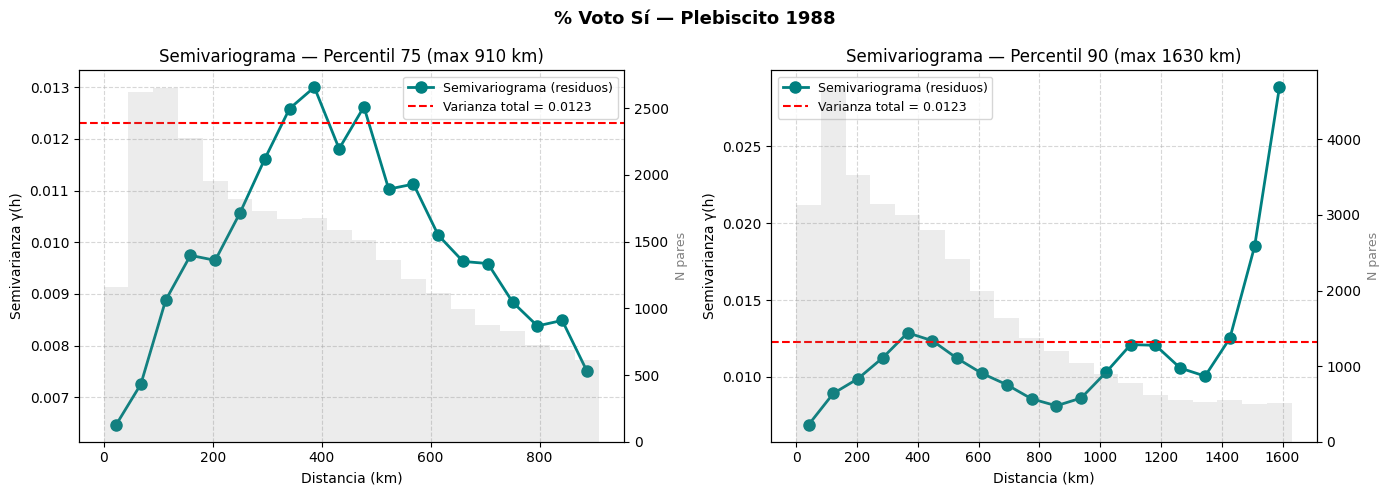

Comunas analizadas: 279


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LinearRegression

print("─── SEMIVARIOGRAMA EMPÍRICO CORREGIDO (RESIDUOS) ───")

# 1. Filtrar filas válidas
df_valid = final_df.dropna(subset=['latitud', 'longitud', 'share_si_88']).copy()

# 2. Remover tendencia espacial lineal antes de calcular semivariograma
coords = df_valid[['latitud', 'longitud']].values
y_raw = df_valid['share_si_88'].values

reg = LinearRegression().fit(coords, y_raw)
z = y_raw - reg.predict(coords)  # residuos sin tendencia espacial

print(f"R² tendencia espacial removida: {reg.score(coords, y_raw):.4f}")
# Si este R² es alto (>0.1), la tendencia importaba y el semivariograma crudo era espurio

# 3. Distancias Haversine
lat = np.radians(df_valid['latitud'].values)
lon = np.radians(df_valid['longitud'].values)

lat_diff = lat[:, np.newaxis] - lat
lon_diff = lon[:, np.newaxis] - lon

a = (np.sin(lat_diff / 2.0)**2 +
     np.cos(lat)[:, np.newaxis] * np.cos(lat) * np.sin(lon_diff / 2.0)**2)
dist_matrix_km = 6371.0 * 2 * np.arcsin(np.sqrt(a))

# 4. Semivarianza por pares
z_diff_sq = squareform(pdist(z.reshape(-1, 1), metric='sqeuclidean'))
idx = np.triu_indices_from(dist_matrix_km, k=1)
distances_km = dist_matrix_km[idx]
variances    = z_diff_sq[idx] / 2.0

# 5. Bins — comparar dos max_dist para detectar truncamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pct, label in zip(axes, [75, 90], ['Percentil 75', 'Percentil 90']):
    max_dist = np.percentile(distances_km, pct)
    num_bins = 20
    bins = np.linspace(0, max_dist, num_bins + 1)

    bin_centers, gamma, n_pairs = [], [], []
    for i in range(num_bins):
        mask = (distances_km >= bins[i]) & (distances_km < bins[i+1])
        if np.any(mask):
            bin_centers.append((bins[i] + bins[i+1]) / 2.0)
            gamma.append(np.mean(variances[mask]))
            n_pairs.append(mask.sum())

    ax.plot(bin_centers, gamma, 'o-', color='teal',
            markersize=8, linewidth=2, label='Semivariograma (residuos)')
    ax.axhline(y=np.var(z), color='red', linestyle='--',
               label=f'Varianza total = {np.var(z):.4f}')

    # Tamaño de muestra por bin (eje secundario)
    ax2 = ax.twinx()
    ax2.bar(bin_centers, n_pairs, width=bin_centers[1]-bin_centers[0],
            alpha=0.15, color='gray', label='N pares')
    ax2.set_ylabel('N pares', color='gray', fontsize=9)

    ax.set_title(f'Semivariograma — {label} (max {max_dist:.0f} km)', fontsize=12)
    ax.set_xlabel('Distancia (km)')
    ax.set_ylabel('Semivarianza γ(h)')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle('% Voto Sí — Plebiscito 1988', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Comunas analizadas: {len(df_valid)}")


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
############################################################
# Recuadro Ganancia Promedio Regional Market Access
############################################################

# 1. Definir ruta de salida explícitamente para evitar NameError
PATH_OUT_DIR = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/'

# 2. Mapeo oficial de regiones
mapeo_orden = {
    'ARICA Y PARINACOTA': 15, 'TARAPACÁ': 1, 'ANTOFAGASTA': 2, 'ATACAMA': 3,
    'COQUIMBO': 4, 'VALPARAÍSO': 5, "LIBERTADOR GENERAL BERNARDO O'HIGGINS": 6,
    'MAULE': 7, 'ÑUBLE': 16, 'BIOBÍO': 8, 'LA ARAUCANÍA': 9, 'LOS RÍOS': 14,
    'LOS LAGOS': 10, 'AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO': 11,
    'MAGALLANES Y DE LA ANTÁRTICA CHILENA': 12, 'METROPOLITANA DE SANTIAGO': 13
}
map_num_a_nombre = {v: k for k, v in mapeo_orden.items()}

# 3. Detectar qué DataFrame está cargado actualmente en la memoria del notebook
df_work = None
for name in ['final_df', 'panel_final_total', 'merged', 'panel_ancho']:
    if name in globals():
        df_work = globals()[name].copy()
        print(f"✅ Detectado y usando el DataFrame: '{name}'")
        break

if df_work is None:
    raise NameError("No se encontró ningún DataFrame conocido en memoria. Asegúrate de correr las celdas de arriba primero.")

# 4. Detectar el nombre de la columna de región
col_reg = None
for col in ['region', 'Region', 'Region_num']:
    if col in df_work.columns:
        col_reg = col
        break

if col_reg is None:
    raise KeyError(f"No se encontró la columna de región. Columnas en el DF: {list(df_work.columns)}")

df_work['Region_nombre'] = df_work[col_reg].map(map_num_a_nombre)

# 5. IDENTIFICAR COLUMNAS DELTA (Filtrando sufijos como local, prov, regional)
sufijos_a_excluir = ['_local', '_prov', '_reg', '_estruct']
cols_delta = [
    c for c in df_work.columns 
    if ('delta_70_80_th_' in c or 'delta_log_MA' in c) 
    and not any(suf in c for suf in sufijos_a_excluir)
]

if not cols_delta:
    raise ValueError(f"No se encontraron columnas de cambios (delta) base. Columnas en el DF: {list(df_work.columns)}")

print(f"Columnas delta base encontradas (sin sufijos): {cols_delta}")

# 6. Promediar y convertir a % de ganancia
df_resumen     = df_work.groupby('Region_nombre')[cols_delta].mean()
df_resumen_pct = (np.exp(df_resumen) - 1) * 100
df_resumen_pct['N_Region'] = df_resumen_pct.index.map(mapeo_orden)
df_final = df_resumen_pct.sort_values('N_Region')

# Limpiar nombres de columnas para que solo digan Theta_X
df_final.columns = [c.replace('delta_70_80_th_', 'Theta_').replace('delta_log_MA_1970_1980', 'Theta_3.8') for c in df_final.columns]

print("=" * 90)
print("GANANCIA PROMEDIO EN MARKET ACCESS (%) POR REGIÓN — 1970 → 1980 (Solo Casos Base)")
print("=" * 90)
display(df_final.round(1).drop(columns=['N_Region']).astype(str) + '%')

# 7. Exportar el archivo
path_out = os.path.join(PATH_OUT_DIR, 'recuadro_ganancias_regional_base_1970.csv')
os.makedirs(PATH_OUT_DIR, exist_ok=True)
df_final.to_csv(path_out)
print(f"\n Exportado exitosamente a: {path_out}")



✅ Detectado y usando el DataFrame: 'final_df'
Columnas delta base encontradas (sin sufijos): ['delta_70_80_th_1', 'delta_70_80_th_4', 'delta_70_80_th_3_8', 'delta_70_80_th_6', 'delta_70_80_th_10', 'delta_70_80_th_12']
GANANCIA PROMEDIO EN MARKET ACCESS (%) POR REGIÓN — 1970 → 1980 (Solo Casos Base)


,Theta_1,Theta_4,Theta_3_8,Theta_6,Theta_10,Theta_12
Region_nombre,,,,,,
TARAPACÁ,6.2%,12.4%,12.7%,12.2%,15.6%,12.8%
ANTOFAGASTA,5.7%,0.6%,-0.1%,9.7%,25.2%,31.3%
ATACAMA,3.4%,-27.4%,-26.0%,-38.9%,-56.4%,-63.1%
COQUIMBO,4.6%,17.9%,16.3%,36.0%,88.7%,124.9%
VALPARAÍSO,15.9%,48.4%,46.8%,66.6%,116.8%,149.4%
LIBERTADOR GENERAL BERNARDO O'HIGGINS,5.7%,4.5%,4.6%,5.1%,8.5%,11.2%
MAULE,4.0%,19.4%,18.4%,28.8%,53.8%,68.8%
BIOBÍO,10.3%,38.4%,36.7%,53.1%,84.4%,103.2%
LA ARAUCANÍA,39.3%,63.5%,60.7%,97.7%,187.4%,245.5%



✅ Exportado exitosamente a: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/recuadro_ganancias_regional_base_1970.csv


In [ ]:

############################################################
# Recuadro Ganancia Media Regional Market Access
############################################################

# 1. Definir ruta de salida
PATH_OUT_DIR = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/'

# 2. Mapeo oficial de regiones
mapeo_orden = {
    'ARICA Y PARINACOTA': 15, 'TARAPACÁ': 1, 'ANTOFAGASTA': 2, 'ATACAMA': 3,
    'COQUIMBO': 4, 'VALPARAÍSO': 5, "LIBERTADOR GENERAL BERNARDO O'HIGGINS": 6,
    'MAULE': 7, 'ÑUBLE': 16, 'BIOBÍO': 8, 'LA ARAUCANÍA': 9, 'LOS RÍOS': 14,
    'LOS LAGOS': 10, 'AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO': 11,
    'MAGALLANES Y DE LA ANTÁRTICA CHILENA': 12, 'METROPOLITANA DE SANTIAGO': 13
}
map_num_a_nombre = {v: k for k, v in mapeo_orden.items()}

# 3. Usar final_df
df_work = final_df.copy()

# 4. Detectar el nombre de la columna de región
col_reg = None
for col in ['region', 'Region', 'Region_num']:
    if col in df_work.columns:
        col_reg = col
        break

if col_reg is None:
    raise KeyError(f"No se encontró la columna de región. Columnas en final_df: {list(df_work.columns)}")

df_work['Region_nombre'] = df_work[col_reg].map(map_num_a_nombre)

# 5. Identificar columnas delta base (sin sufijos)
sufijos_a_excluir = ['_local', '_prov', '_reg', '_estruct']
cols_delta = [
    c for c in df_work.columns 
    if ('delta_70_80_th_' in c or 'delta_log_MA' in c) 
    and not any(suf in c for suf in sufijos_a_excluir)
]

if not cols_delta:
    raise ValueError(f"No se encontraron columnas de cambios (delta) base en final_df. Columnas disponibles: {list(df_work.columns)}")

print(f"Columnas delta base encontradas: {cols_delta}")

# 6. Calcular MEDIANAS por región y convertir a % de ganancia
df_mediana     = df_work.groupby('Region_nombre')[cols_delta].median()
df_mediana_pct = (np.exp(df_mediana) - 1) * 100
df_mediana_pct['N_Region'] = df_mediana_pct.index.map(mapeo_orden)
df_final_robusto = df_mediana_pct.sort_values('N_Region')

# Limpiar nombres de columnas para que solo digan Theta_X
df_final_robusto.columns = [c.replace('delta_70_80_th_', 'Theta_').replace('delta_log_MA_1970_1980', 'Theta_3.8') for c in df_final_robusto.columns]

print("=" * 100)
print("RECUADRO ROBUSTO (MEDIANAS): % GANANCIA MARKET ACCESS POR REGIÓN — 1970 → 1980 (Solo Casos Base)")
print("═" * 100)
display(df_final_robusto.round(1).drop(columns=['N_Region']).astype(str) + '%')

# 7. Exportar
path_robusto = os.path.join(PATH_OUT_DIR, 'recuadro_mediana_ganancias_regional_base_1970.csv')
os.makedirs(PATH_OUT_DIR, exist_ok=True)
df_final_robusto.to_csv(path_robusto)
print(f"\n Cuadro robusto exportado a: {path_robusto}")


Columnas delta base encontradas: ['delta_70_80_th_1', 'delta_70_80_th_4', 'delta_70_80_th_3_8', 'delta_70_80_th_6', 'delta_70_80_th_8_22', 'delta_70_80_th_10', 'delta_70_80_th_12']
RECUADRO ROBUSTO (MEDIANAS): % GANANCIA MARKET ACCESS POR REGIÓN — 1970 → 1980 (Solo Casos Base)
════════════════════════════════════════════════════════════════════════════════════════════════════


,Theta_1,Theta_4,Theta_3_8,Theta_6,Theta_8_22,Theta_10,Theta_12
Region_nombre,,,,,,,
TARAPACÁ,7.4%,-20.2%,-18.6%,-34.5%,-47.6%,-56.2%,-64.0%
ANTOFAGASTA,6.6%,-2.2%,-2.3%,-0.9%,-0.3%,-0.1%,-0.0%
ATACAMA,3.5%,-20.3%,-19.3%,-29.0%,-37.4%,-43.5%,-49.6%
COQUIMBO,4.8%,10.5%,10.2%,17.9%,36.5%,49.1%,63.3%
VALPARAÍSO,14.3%,36.2%,39.8%,41.7%,51.4%,62.0%,76.0%
LIBERTADOR GENERAL BERNARDO O'HIGGINS,4.8%,-4.0%,-3.7%,-2.7%,-1.7%,-2.9%,-1.9%
MAULE,4.4%,5.2%,5.7%,2.7%,1.0%,0.4%,0.2%
BIOBÍO,9.5%,13.9%,13.9%,12.8%,10.8%,12.5%,0.8%
LA ARAUCANÍA,36.2%,34.1%,34.5%,46.8%,62.6%,64.0%,63.3%



✅ Cuadro robusto exportado a: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/recuadro_mediana_ganancias_regional_base_1970.csv


✅ Usando la columna de MA en escala logarítmica: 'delta_70_80_th_4'


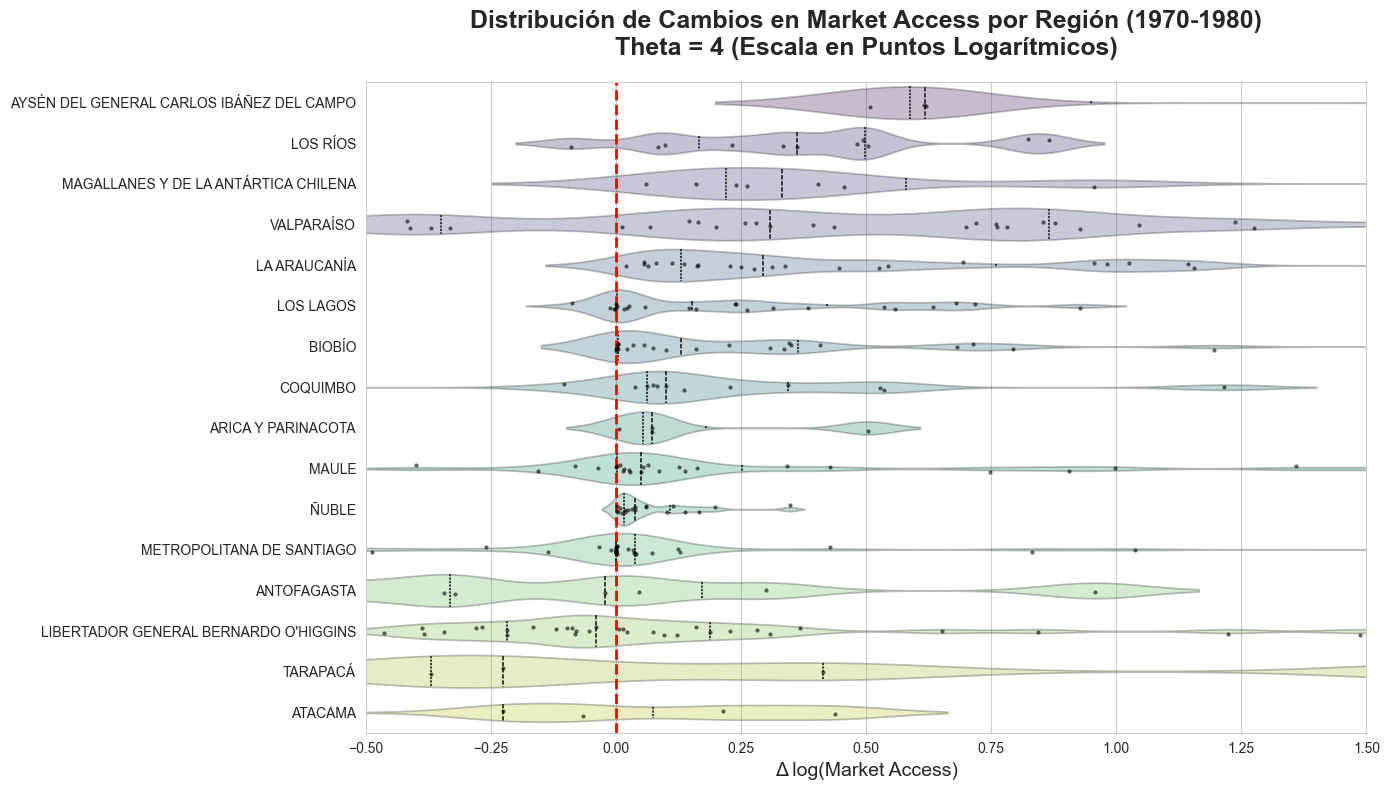

✅ Gráfico logarítmico guardado en: /Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/violin_plot_ganancias_log.jpg


In [ ]:
#######################################################
## Gráfico de Violín - Market Access (Puntos Logarítmicos)
#######################################################

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. Definir ruta de salida
PATH_OUT_DIR = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/'

# 2. Mapeo oficial de regiones
mapeo_orden = {
    'ARICA Y PARINACOTA': 15, 'TARAPACÁ': 1, 'ANTOFAGASTA': 2, 'ATACAMA': 3,
    'COQUIMBO': 4, 'VALPARAÍSO': 5, "LIBERTADOR GENERAL BERNARDO O'HIGGINS": 6,
    'MAULE': 7, 'ÑUBLE': 16, 'BIOBÍO': 8, 'LA ARAUCANÍA': 9, 'LOS RÍOS': 14,
    'LOS LAGOS': 10, 'AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO': 11,
    'MAGALLANES Y DE LA ANTÁRTICA CHILENA': 12, 'METROPOLITANA DE SANTIAGO': 13
}
map_num_a_nombre = {v: k for k, v in mapeo_orden.items()}

# 3. Usar final_df
plot_df = final_df.copy()

col_reg = None
for col in ['region', 'Region', 'Region_num']:
    if col in plot_df.columns:
        col_reg = col
        break

if col_reg is None:
    raise KeyError(f"No se encontró la columna de región en final_df. Columnas disponibles: {list(plot_df.columns)}")

plot_df['Nombre Region'] = plot_df[col_reg].map(map_num_a_nombre)
plot_df = plot_df.dropna(subset=['Nombre Region'])

# 4. Encontrar columna Theta=4 (o similar)
col_ma = None
# Priorizamos columnas asociadas a theta 4
for col in ['delta_70_80_th_4', 'delta_log_MA_1970_1980', 'delta_log_MA']:
    if col in plot_df.columns:
        col_ma = col
        break

if col_ma is None:
    raise ValueError(f"No se encontró la columna de MA. Columnas disponibles: {list(plot_df.columns)}")

print(f" Usando la columna de MA en escala logarítmica: '{col_ma}'")

# Reemplazamos el cálculo porcentual por los puntos logarítmicos puros
plot_df['Gain_Log'] = plot_df[col_ma]

# Ordenamos las regiones por la mediana logarítmica descendente
order = plot_df.groupby('Nombre Region')['Gain_Log'] \
               .median() \
               .sort_values(ascending=False) \
               .index

# 5. Gráfico
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", len(order))

# Graficar violines (densidad)
ax = sns.violinplot(
    data=plot_df, 
    x='Gain_Log', 
    y='Nombre Region', 
    order=order,
    palette=palette,
    inner="quartile",
    bw_adjust=0.3  # bw_adjust es el parámetro moderno en seaborn
)

# Hacer violines semitransparentes
for collection in ax.collections:
    collection.set_alpha(0.3)

# Dibujar puntos individuales sobre los violines
sns.stripplot(
    data=plot_df, 
    x='Gain_Log', 
    y='Nombre Region', 
    order=order,
    size=3,
    color="black",
    alpha=0.6
)

# Línea vertical en 0 (sin ganancia logarítmica)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)

# Estética y Etiquetas
plt.title('Distribución de Cambios en Market Access por Región (1970-1980)\nTheta = 4 (Escala en Puntos Logarítmicos)',
          fontsize=18, fontweight='bold', pad=20)

plt.xlabel('Δ log(Market Access)', fontsize=14)
plt.ylabel('')

# Ajustamos límites de visibilidad para la escala log
plt.xlim(-0.5, 1.5)
plt.tight_layout()

# 6. Guardar y Exportar
os.makedirs(PATH_OUT_DIR, exist_ok=True)
plt.savefig(os.path.join(PATH_OUT_DIR, 'violin_plot_ganancias_log.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f" Gráfico logarítmico guardado en: {PATH_OUT_DIR}violin_plot_ganancias_log.jpg")


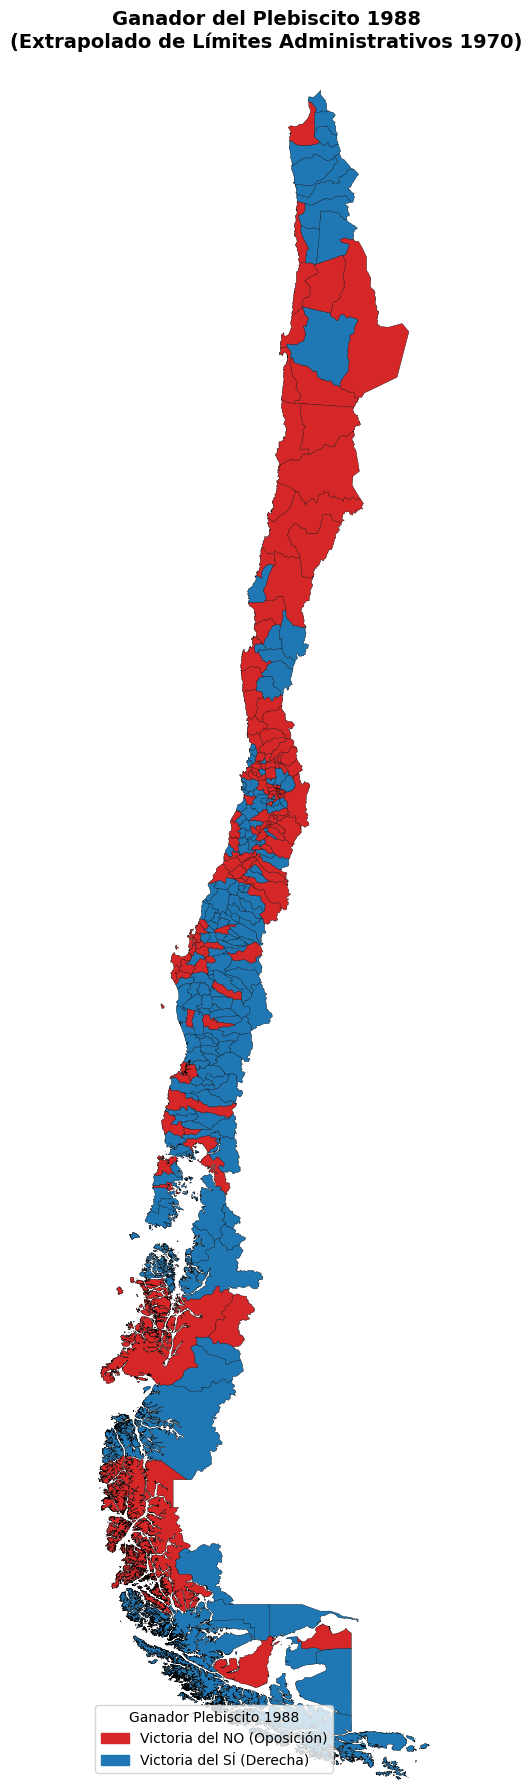

In [17]:
### CELDA: EXTRAPOLACIÓN PLEBISCITO 1988 A LIMITES 1970 (MAPA CATEGÓRICO 100%) ###
# --------------------------------------------------------------------------------

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import unicodedata, re
from difflib import get_close_matches
import warnings
warnings.filterwarnings('ignore')

# 1. Rutas (Base bruta 1988, Shapefile 1970 y Diccionario Madre-Hija)
PATH_MAP = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/market_access/mapping_1970_2024.csv'
PATH_PLEB = '/Users/Angelo/Dropbox/Tesis 2026 ME/Procesos Tesis/Data/outcomes/elecciones/Resultados_plebiscito_88.dta'
PATH_SHP_1970 = '/Users/Angelo/Dropbox/DPA Historica/Comunas_1970.shp'

df_map = pd.read_csv(PATH_MAP)
df_pleb = pd.read_stata(PATH_PLEB)
gdf_1970 = gpd.read_file(PATH_SHP_1970)

# 2. Función de normalización
def normalizar(txt):
    if pd.isna(txt): return ''
    txt = str(txt).strip().upper()
    txt = unicodedata.normalize('NFD', txt)
    txt = ''.join(c for c in txt if unicodedata.category(c) != 'Mn')
    txt = re.sub(r'[^A-Z ]', '', txt)
    return txt

# 3. Construir el mapeo Hija (1988/2024) -> Madre (1970)
df_map['hija'] = df_map['commune_2024'].apply(normalizar)
df_map['madre'] = df_map['mother_1970'].apply(normalizar)
mapa_hija_madre = dict(zip(df_map['hija'], df_map['madre']))

# Ajustes manuales para zonas australes remotas
mapa_hija_madre['NAVARINO'] = 'NAVARINO'
mapa_hija_madre['ANTARTICA'] = 'ANTARTICA'
mapa_hija_madre['AYSEN'] = 'AISEN'

# 4. Procesar la base bruta del Plebiscito 1988
df_pleb['comuna_norm'] = df_pleb['comuna'].apply(normalizar)

# Asignar a cada comuna de 1988 su comuna madre de 1970
def map_to_mother(c):
    if c in mapa_hija_madre: return mapa_hija_madre[c]
    matches = get_close_matches(c, list(mapa_hija_madre.keys()), n=1, cutoff=0.7)
    if matches: return mapa_hija_madre[matches[0]]
    return c 

df_pleb['mother_1970'] = df_pleb['comuna_norm'].apply(map_to_mother)

# Sumar votos a nivel de comuna madre
df_pleb['vsi_numeric'] = pd.to_numeric(df_pleb['vsi_pleb88'], errors='coerce').fillna(0)
df_pleb['vno_numeric'] = pd.to_numeric(df_pleb['vno_pleb88'], errors='coerce').fillna(0)

pleb_grouped = df_pleb.groupby('mother_1970')[['vsi_numeric', 'vno_numeric']].sum().reset_index()

# Calcular el % del SÍ y determinar ganador
pleb_grouped['share_si_88'] = pleb_grouped['vsi_numeric'] / (pleb_grouped['vsi_numeric'] + pleb_grouped['vno_numeric'])

def definir_ganador(share_si):
    if pd.isna(share_si): return None
    elif share_si > 0.5: return 'Gana SÍ'
    else: return 'Gana NO'

pleb_grouped['ganador_88'] = pleb_grouped['share_si_88'].apply(definir_ganador)

# 5. Limpieza y corrección de nombres corruptos en el Shapefile 1970
gdf_1970['comuna_norm'] = gdf_1970['COMUNA'].apply(normalizar)

alias_shp = {
    'ALHUA': 'ALHUE', 'BELAN': 'BELEN', 'CHAITAN': 'CHAITEN', 'CHAPICA': 'CHEPICA',
    'COANCO': 'COINCO', 'COLBAN': 'COLBUN', 'CONCHALA': 'CONCHALI',
    'CONSTITUCIAN': 'CONSTITUCION', 'COPIAPA': 'COPIAPO', 'CURACAUTAN': 'CURACAUTIN',
    'CURACAVA': 'CURACAVI', 'CURACO DE VALEZ': 'CURACO DE VELEZ', 'CURICA': 'CURICO',
    'FUTALEUFA': 'FUTALEUFU', 'LA UNIAN': 'LA UNION', 'LICANTAN': 'LICANTEN',
    'LONGAVA': 'LONGAVI', 'MACHALA': 'MACHALI', 'MAIPA': 'MAIPU', 
    'MARAA PINTO': 'MARIA PINTO', 'MAULLAN': 'MAULLIN', 'MULCHAN': 'MULCHEN',
    'OLMUA': 'OLMUE', 'PUCAN': 'PUCON', 'PUCHUNCAVA': 'PUCHUNCAVI',
    'PUQUELDAN': 'PUQUELDON', 'PURAN': 'PUREN', 'QUEILAN': 'QUEILEN',
    'QUELLAN': 'QUELLON', 'QUILLAN': 'QUILLON', 'QUILPUA': 'QUILPUE',
    'RAO BUENO': 'RIO BUENO', 'RAO CLARO': 'RIO CLARO', 'RAO NEGRO': 'RIO NEGRO',
    'REQUANOA': 'REQUINOA', 'SAN JOSA DE MAIPO': 'SAN JOSE DE MAIPO',
    'SANTA MARAA': 'SANTA MARIA', 'TOLTAN': 'TOLTEN', 'TOMA': 'TOME',
    'TRAIGUAN': 'TRAIGUEN', 'VALPARAASO': 'VALPARAISO', 'VICHUQUAN': 'VICHUQUEN',
    'VILCAN': 'VILCUN', 'SANTIAGO SUR': 'SANTIAGO', 'SANTIAGO OESTE': 'SANTIAGO',
    'SANTIAGO ESTE': 'SANTIAGO', 'SANTIAGO CENTRO': 'SANTIAGO', 
    'CHAAARAL': 'CHANARAL', 'VIAA DEL MAR': 'VINA DEL MAR', 'PEAAFLOR': 'PENAFLOR',
    'DOAIHUE': 'DONIHUE', 'HUALAAA': 'HUALANE', 'AIQUEN': 'NIQUEN',
    'CAAETE': 'CANETE', 'VICUAA': 'VICUNA', 'RAUCO': 'ARAUCO',
    'AUAOA': 'NUNOA', 'AYSAN': 'AISEN', 'BAHAA INATIL': 'BAHIA INUTIL',
    'COCHAMA': 'COCHAMO', 'CONCEPCIAN': 'CONCEPCION', 'PITRUFQUAN': 'PITRUFQUEN', 
    'RAO IBAAEZ': 'RIO IBANEZ', 'RAO VERDE': 'RIO VERDE', 'LA ANTARTICA': 'ANTARTICA'
}
gdf_1970['comuna_norm'] = gdf_1970['comuna_norm'].replace(alias_shp)
gdf_1970 = gdf_1970.dissolve(by='comuna_norm').reset_index()

# 6. Merge Espacial principal
mapa_plebiscito = gdf_1970.merge(
    pleb_grouped, 
    left_on='comuna_norm', 
    right_on='mother_1970',
    how='left'
)

# 7. HEREDAR VOTOS: Las comunas muertas heredan el color de la comuna futura que las absorbió
heredar_votos = {
    'AGUAS BLANCAS': 'ANTOFAGASTA',
    'CATALINA': 'TALTAL',
    'LAGUNAS': 'POZO ALMONTE',
    'BELEN': 'PUTRE',
    'CORCOVADO': 'CHAITEN',
    'BAHIA INUTIL': 'TIMAUKEL'
}

for muerta, viva in heredar_votos.items():
    if viva in pleb_grouped['mother_1970'].values:
        ganador_viva = pleb_grouped.loc[pleb_grouped['mother_1970'] == viva, 'ganador_88'].values[0]
        mapa_plebiscito.loc[mapa_plebiscito['comuna_norm'] == muerta, 'ganador_88'] = ganador_viva

# 8. Graficar
fig, ax = plt.subplots(1, 1, figsize=(10, 18))

# Colores directos
color_dict = {'Gana SÍ': '#1f77b4', 'Gana NO': '#d62728'}

# Base en gris (por si existe algún territorio literal sin datos, casi imposible)
mapa_plebiscito.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.1)

# Pintar todo el territorio con datos 
for categoria, color in color_dict.items():
    subset = mapa_plebiscito[mapa_plebiscito['ganador_88'] == categoria]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor='black', linewidth=0.2)

import matplotlib.patches as mpatches
leyenda_si = mpatches.Patch(color='#1f77b4', label='Victoria del SÍ (Derecha)')
leyenda_no = mpatches.Patch(color='#d62728', label='Victoria del NO (Oposición)')
ax.legend(handles=[leyenda_no, leyenda_si], title="Ganador Plebiscito 1988", loc='lower left', fontsize=10)

ax.set_title('Ganador del Plebiscito 1988\n(Extrapolado de Límites Político Administrativos 1970)', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

# Limitar zoom continental
ax.set_xlim([-76, -66])
ax.set_ylim([-56, -17])

plt.tight_layout()
plt.show()
